In [1]:
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime
import geopandas as gpd
import numpy as np
import os
import pathlib
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker



In [2]:
HOME_DIR = pathlib.Path.home()
# in my (AO) case, M:\urban_modeling is mounted to /Volumes/Data/Models/urban_modeling
M_DRIVE = pathlib.Path('/Volumes/Data/Models') if os.name=='posix' else pathlib.Path('M:/')

box_path = HOME_DIR / 'Library/CloudStorage/Box-Box'
data_base_path = M_DRIVE / 'Data/Census/PUMS'
data_base_path

WindowsPath('M:/Data/Census/PUMS')

# Mappings and correspondences

In [3]:
# psrc = {'53033':'King',
# '53035':'Kitsap' ,
# '53053':'Pierce',
# '53061':'Snohomish'}

In [4]:
ca_fips_path = M_DRIVE / 'Crosswalks/geo/st06_ca_cou2020.txt'
ca_fips = pd.read_csv(ca_fips_path, sep='|', dtype=str)
ca_fips['STCOUNTY'] = ca_fips.STATEFP+ca_fips.COUNTYFP
ca_fips['county_name'] = ca_fips.COUNTYNAME.str.replace(
    ' County', '').str.strip()
ca_fips = ca_fips.set_index('STCOUNTY').county_name
ca_fips

STCOUNTY
06001            Alameda
06003             Alpine
06005             Amador
06007              Butte
06009          Calaveras
06011             Colusa
06013       Contra Costa
06015          Del Norte
06017          El Dorado
06019             Fresno
06021              Glenn
06023           Humboldt
06025           Imperial
06027               Inyo
06029               Kern
06031              Kings
06033               Lake
06035             Lassen
06037        Los Angeles
06039             Madera
06041              Marin
06043           Mariposa
06045          Mendocino
06047             Merced
06049              Modoc
06051               Mono
06053           Monterey
06055               Napa
06057             Nevada
06059             Orange
06061             Placer
06063             Plumas
06065          Riverside
06067         Sacramento
06069         San Benito
06071     San Bernardino
06073          San Diego
06075      San Francisco
06077        San Joaquin
06079    San Lui

In [23]:
# Bay Area counties
bayareafips_full = {
    '06001': 'Alameda County',
    '06013': 'Contra Costa County',
    '06041': 'Marin County',
    '06055': 'Napa County',
    '06075': 'San Francisco County',
    '06081': 'San Mateo County',
    '06085': 'Santa Clara County',
    '06097': 'Sonoma County',
    '06095': 'Solano County',
}

bayareareg = {k: 'ABAG/MTC' for k in bayareafips_full}

# For vicinity counties, rely on the regionalization in:
# http://www.cdss.ca.gov/research/res/pdf/multireports/RegionsofCalifornia.pdf

nbhfips = {
    '06077': 'San Joaquin',
    '06099': 'Stanislaus',
    '06067': 'Sacramento',
    '06047': 'Merced',
    '06113': 'Yolo',
    '06115': 'Yuba',
    '06101': 'Sutter',
    '06017': 'El Dorado',
    '06061': 'Placer',
    '06087': 'Santa Cruz',
    '06069': 'San Benito',
    '06053': 'Monterey',
    '06033': 'Lake',
    '06045': 'Mendocino',
}


nbhtype = {
    '06077': 'Southern Farm',
    '06047': 'Southern Farm',
    '06099': 'Southern Farm',
    '06069': 'Southern Farm',
    #'06067': 'Vicinity Central Valley',
    #'06113': 'Vicinity Central Valley',
    #'06115': 'Vicinity Central Valley',
    #'06101': 'Vicinity Central Valley',
    #'06017': 'Vicinity Central Valley',
    #'06061': 'Vicinity Central Valley',
    '06087': 'Southern Coast',
    '06053': 'Southern Coast',
    '06033': 'North and Mountains',
    '06045': 'North and Mountains',
    '06017': 'Greater Sacramento Area',      # El Dorado
    '06061': 'Greater Sacramento Area',      # Placer
    '06067': 'Greater Sacramento Area',      # Sacramento
    '06101': 'Greater Sacramento Area',      # Sutter
    '06113': 'Greater Sacramento Area',      # Yolo
    '06115': 'Greater Sacramento Area',      # Yuba
}

# Concatenate the dicts
bayareareg_w_nbhs = bayareareg | nbhtype
bayareafips_w_nbhs = bayareafips_full | nbhtype

cog_regions = {
    # ABAG/MTC
    '06001': 'ABAG/MTC',   # Alameda
    '06013': 'ABAG/MTC',   # Contra Costa
    '06041': 'ABAG/MTC',   # Marin
    '06055': 'ABAG/MTC',   # Napa
    '06075': 'ABAG/MTC',   # San Francisco
    '06081': 'ABAG/MTC',   # San Mateo
    '06085': 'ABAG/MTC',   # Santa Clara
    '06095': 'ABAG/MTC',   # Solano
    '06097': 'ABAG/MTC',   # Sonoma
    # SACOG
    '06017': 'SACOG',      # El Dorado
    '06061': 'SACOG',      # Placer
    '06067': 'SACOG',      # Sacramento
    '06101': 'SACOG',      # Sutter
    '06113': 'SACOG',      # Yolo
    '06115': 'SACOG',      # Yuba
    # SCAG
    '06025': 'SCAG',       # Imperial
    '06037': 'SCAG',       # Los Angeles
    '06059': 'SCAG',       # Orange
    '06065': 'SCAG',       # Riverside
    '06071': 'SCAG',       # San Bernardino
    '06111': 'SCAG',       # Ventura
    # Other COGs
    '06047': 'MCAG',       # Merced
    '06053': 'AMBAG',      # Monterey
    '06069': 'AMBAG',      # San Benito
    '06087': 'AMBAG',      # Santa Cruz
    '06077': 'SJCOG',      # San Joaquin
    '06099': 'STANCOG',    # Stanislaus
    '06073': 'SANDAG',     # San Diego    
    # Other
    '06033': 'Rest of CA', # Lake
    '06045': 'Mendocino CAG',
}

In [8]:
# state abbreviations

state_abbrev = pd.read_csv('https://www2.census.gov/geo/docs/reference/state.txt',sep='|',dtype=str)
state_abbrev.head(5)

,STATE,STUSAB,STATE_NAME,STATENS
0,01,AL,Alabama,01779775
1,02,AK,Alaska,01785533
2,04,AZ,Arizona,01779777
3,05,AR,Arkansas,00068085
4,06,CA,California,01779778


## Convenience functions

In [9]:
def geoprocessor(df, puma_to_county):

    # concatenate state and puma for unique identification
    df['STPUMA'] = df.apply(
        lambda x: f'{x.ST:02d}{x.PUMA:05d}', axis=1)

    df['county_name'] = df['STPUMA'].map(
        puma_to_county).str.replace(' County (CA)', '', regex=False)
    
    hh_bayarea_19_mask = df.county_name.isin(ca_fips.values())

    hh_bayarea_19 = df.loc[hh_bayarea_19_mask]
    return hh_bayarea_19

In [10]:
def age_summary_wrapper(df, qry, grp):
    subset = df.query(qry)
    result = subset.groupby(grp).apply(
        weighted_average_and_se,  slug='avg', var='AGEP', wgt='PWGTP')
    return result

In [11]:
def format_labels(cut_bins, format_strings):
    """concenience function for generating label from a list of cutoff points."""
    labels = [*(f'{a+1}-{b}' for a, b in zip(cut_bins[:-1], cut_bins[1:]))]
    labels[0] = format_strings[0] % cut_bins[1]
    labels[-1] = format_strings[-1] % cut_bins[-2]
    return labels

age_bins = range(0,86,10)
format_strings = ['< %s', '%s-%s',  '> %s']
age_labels = format_labels(age_bins, format_strings)
age_labels

['< 10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '> 70']

In [12]:

def calculate_replicate_se(primary_estimate, replicate_estimates, years=1):
    """
    Calculate standard error using replicate weights methodology.

    Args:
        primary_estimate: Estimate using primary weights
        replicate_estimates: Series of estimates using replicate weights
        years: Number of years the data represents (default: 1)

    Returns:
        float: Standard error
    """
    squared_diffs = (replicate_estimates - primary_estimate) ** 2
    variance = (4 / (80 * years)) * squared_diffs.sum()
    return np.sqrt(variance)


def calculate_confidence_interval(estimate, standard_error, confidence_level=0.90):
    """
    Calculate confidence interval and margin of error.

    Args:
        estimate: Point estimate
        standard_error: Standard error of the estimate
        confidence_level: Confidence level (default: 0.90 for 90% CI)

    Returns:
        dict with 'moe', 'ci_lower', 'ci_upper'
    """
    # note that Z-score for 90% confidence interval is 1.645 - 95% is 1.96
    z_score = 1.645 if confidence_level == 0.90 else 1.96
    
    moe = standard_error * z_score
    ci_upper = estimate + moe
    ci_lower = max(0, estimate - moe)  # Ensure non-negative

    return {
        'moe': moe,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }


def estimate_total_with_se(grouped_df, weight='PWGTP', years=1):
    """
    Calculate total estimate with standard errors using ACS PUMS replicate weights.

    This function calculates the total (sum) of a weighted variable along with
    associated standard errors, margins of error, and confidence intervals using
    the replicate weight methodology.

    Args:
        grouped_df: DataFrame or GroupBy object containing ACS PUMS data
        weight: Column name for primary weight (default: 'PWGTP')
        years: Number of years the data represents (default: 1)

    Returns:
        pd.Series with the following statistics:
            - 'total': Total estimate
            - 'se': Standard error
            - 'moe': Margin of error (90% CI)
            - 'ci_lower': Lower bound of 90% confidence interval
            - 'ci_upper': Upper bound of 90% confidence interval
            - 'cv': Coefficient of variation
            - 'sample_size': Number of records
    """
    # Identify replicate weight columns (PWGTP1, PWGTP2, ..., PWGTP80)
    repwgt_pattern = f'{weight}\\d{{1,2}}'

    # Calculate estimates (main weight, as well as replicates)
    primary_estimate = grouped_df[weight].sum() / float(years)
    replicate_estimates = grouped_df.filter(regex=repwgt_pattern).sum()

    # Calculate standard error
    se = calculate_replicate_se(primary_estimate, replicate_estimates, years)

    # Calculate confidence interval
    ci = calculate_confidence_interval(primary_estimate, se)

    # Coefficient of variation
    cv = se / primary_estimate if primary_estimate != 0 else np.inf

    return pd.Series({
        'total': int(primary_estimate),
        'se': se,
        'moe': ci['moe'],
        'ci_lower': np.ceil(ci['ci_lower']),
        'ci_upper': np.ceil(ci['ci_upper']),
        'cv': cv,
        'sample_size': grouped_df.shape[0]
    })



In [13]:
pct = lambda x: x/x.sum()

# Load PUMS data

In [14]:
import re

# dictionary of known column aliases across vintages
COLUMN_ALIASES = {
    "STATE": ["ST", "STATE"],
    "PUMA": ["PUMA", "PUMA00", "PUMA10"],
    "SERIALNO": ["SERIALNO"],
    "JWTR":["JWTR","JWTRNS"],
    "AGEP": ["AGEP", "AGE"],  # name varies
}

def resolve_columns(file_path, keep_cols, verbose=True):
    """Resolve which actual columns to load from a file header."""
    header = pd.read_csv(file_path, nrows=0)
    available = header.columns.tolist()

    available_upper = {col.upper(): col for col in available}

    pwgt_re = re.compile(r'^PWGTP([1-9]|[1-7]\d|80)$', re.IGNORECASE)
    pwgtp_cols = [
        (int(m.group(1)), col)
        for col in available
        if (m := pwgt_re.match(col))
    ]

    col_map = {}
    for c in keep_cols:
        uc = c.upper()

        if uc.startswith("PWGTP") and len(uc) > 5 and uc[5:].isdigit():
            if not pwgtp_cols:
                if verbose:
                    print(f"    Warning: replicate weights not found in {file_path.name}")
                continue
            for idx, actual_col in pwgtp_cols:
                col_map[f"PWGTP{idx}"] = actual_col
            continue

        if uc in available_upper:
            col_map[c] = available_upper[uc]
        elif uc in COLUMN_ALIASES:
            for alias in COLUMN_ALIASES[uc]:
                if alias in available_upper:
                    col_map[c] = available_upper[alias]
                    break

    return col_map
    
def load_pums_year(base_path, year, keep_cols, verbose=True):
    base = pathlib.Path(base_path)
    year_path = base / f"PUMS {year}"
    if verbose:
        print(f"\nLoading PUMS {year}")

    # this should work with both the psam_pus and the older ss15pusa patterns
    patterns = ["psam_pus*.csv", f"ss{str(year)[-2:]}pus*.csv"]
    files = []
    for pat in patterns:
        files.extend(sorted(year_path.glob(pat)))

    if not files:
        raise FileNotFoundError(f"No PUMS CSVs found under {year_path}")

    keep_cols_set = set(keep_cols)  # Create once, reuse for all files
    
    dfs = []
    for f in files:
        if verbose:
            print(f"  → Resolving columns in {f.name}")
        col_map = resolve_columns(f, keep_cols_set, verbose=verbose)
        if verbose:
            print(
                f"    Column mapping resolved: {list(col_map.items())[:10]}{' ...' if len(col_map) > 10 else ''}")

        if not col_map:
            raise ValueError(f"No requested columns found in {f.name}")

        df = pd.read_csv(f, usecols=list(col_map.values()))
        df = df.rename(columns={v: k for k, v in col_map.items()})
        df["year"] = year
        dfs.append(df)
        if verbose:
            print(f"    Loaded shape {df.shape}")

    out = pd.concat(dfs, ignore_index=True)
    if verbose:
        print(f"Finished PUMS {year}. Final shape: {out.shape}")
    return out


def load_pums_multi(base_path, years, keep_cols, verbose=True):
    "Wrap the single year loader."
    all_dfs = []
    if verbose:
        print(f"=== Starting multi-year load: {years} ===")
    for y in years:
        df_year = load_pums_year(base_path, y, keep_cols, verbose=verbose)
        all_dfs.append(df_year)
    out = pd.concat(all_dfs, ignore_index=True)
    if verbose:
        print(f"=== Finished multi-year load. Combined shape: {out.shape} ===")
    return out

In [15]:


def get_cpi_adjustment_factors(
    start_year: int = 2015,
    end_year: int = 2024,
    base_year: int = 2024,
    series: str = "CPIAUCSL",          # code for all-items CPI, urban consumers
) -> dict[int, float]:
    """
    Pull annual average CPI from FRED and return a dict mapping each sample
    year to a multiplicative factor that converts that year's dollars to
    `base_year` dollars.

    Factor interpretation:
        wage_2024_dollars = raw_wage * factor[sample_year]

    A factor > 1 means wages are inflated upward (older years).
    The base_year factor is exactly 1.0.
    """
    raw = web.DataReader(
        series,
        "fred",
        start=datetime(start_year, 1, 1),
        end=datetime(end_year, 12, 31),
    )

    # Annual average CPI for each calendar year
    annual_cpi: dict[int, float] = (
        raw[series]
        .resample("YE")          # year-end anchor → one row per year
        .mean()
        .rename(lambda ts: ts.year)
        .to_dict()
    )

    base_cpi = annual_cpi[base_year]

    factors = {year: base_cpi / cpi for year, cpi in annual_cpi.items()}
    return factors

    
def add_constant_dollar_wage(
    df: pd.DataFrame,
    cpi_factors: dict[int, float],
    wage_col: str = "WAGP",
    year_col: str = "year",
    adj_col: str = "ADJINC",
    out_col: str = "WAGP_2024",
) -> None:
    """
    Add a constant-dollar wage column to a PUMS DataFrame **in place**.

    Applies the native ADJINC adjustment first (converts to mid-year dollars
    for each sample year), then applies CPI factors to bring all years to
    constant 2024 dollars.
    """
    missing = set(df[year_col].unique()) - set(cpi_factors)
    if missing:
        raise ValueError(
            f"No CPI factor available for sample years: {sorted(missing)}. "
            "Expand the range in get_cpi_adjustment_factors()."
        )

    df[out_col] = (
        df[wage_col]
        * (df[adj_col] / 1_000_000)        # ADJINC: 6 implied decimal places so divide by 1m
        * df[year_col].map(cpi_factors)    # CPI: bring to 2024 dollars
    )


In [16]:
def format_labels(cut_bins, format_strings):
    """Convenience function for generating labels from a list of cutoff points."""
    labels = [format_strings[1] % (a + 1, b) for a, b in zip(cut_bins[:-1], cut_bins[1:])]
    labels[0] = format_strings[0] % cut_bins[1]
    labels[-1] = format_strings[-1] % cut_bins[-2]
    return labels


def bin_wage_workers(
    df: pd.DataFrame,
    cutoffs: list[float],
    format_strings: list[str],
    wage_col: str = "WAGP_2024",
    out_col: str = "wage_tier",
    workers_only: bool = True,
) -> None:
    """
    Bin workers into wage categories **in place**.

    Parameters
    ----------
    cutoffs        : bin edges, e.g. [0, 30_000, 60_000, 100_000, inf]
    format_strings : three-element list ['< %s', '%s-%s', '> %s'] passed
                     to format_labels() to generate the category labels.
    """
    labels = format_labels(cutoffs, format_strings)

    if workers_only:
        mask = df[wage_col] > 0
        df.loc[mask, out_col] = pd.cut(
            df.loc[mask, wage_col],
            bins=cutoffs,
            labels=labels,
            right=False,
            include_lowest=True,
        )
    else:
        df[out_col] = pd.cut(
            df[wage_col],
            bins=cutoffs,
            labels=labels,
            right=False,
            include_lowest=True,
        )
    # since the df is probably large, assign in place rather than return a full df
    df[out_col] = pd.Categorical(df[out_col], categories=labels, ordered=True)

In [17]:
# call the national files for select years - so we don't run out of memory

years = [2013, 2015,2017,2019,2021,2023]  
years = [2015, 2019, 2021, 2024]   
#keep_cols = ["STATE", "PUMA", "SERIALNO", "SPORDER", "AGEP","PWGTP","MAR","SEX","MARHM","MARHT"]
keep_cols =  ["STATE", "PUMA", "SERIALNO","AGEP","PWGTP","NAICSP","JWMNP","JWTR", "ESR","SEX",
              "SCHG","NP","OC","RELP","MIG","MIGSP","MIGPUMA","POWSP","POWPUMA","WAGP","ADJINC"
             ] + [f"PWGTP{i}" for i in range(1,81)]

pums_combo = load_pums_multi(data_base_path, years, keep_cols)

=== Starting multi-year load: [2015, 2019, 2021, 2024] ===

Loading PUMS 2015
  → Resolving columns in ss15pusa.csv
    Column mapping resolved: [('PWGTP1', 'pwgtp1'), ('PWGTP2', 'pwgtp2'), ('PWGTP3', 'pwgtp3'), ('PWGTP4', 'pwgtp4'), ('PWGTP5', 'pwgtp5'), ('PWGTP6', 'pwgtp6'), ('PWGTP7', 'pwgtp7'), ('PWGTP8', 'pwgtp8'), ('PWGTP9', 'pwgtp9'), ('PWGTP10', 'pwgtp10')] ...
    Loaded shape (1618489, 101)
  → Resolving columns in ss15pusb.csv
    Column mapping resolved: [('PWGTP1', 'pwgtp1'), ('PWGTP2', 'pwgtp2'), ('PWGTP3', 'pwgtp3'), ('PWGTP4', 'pwgtp4'), ('PWGTP5', 'pwgtp5'), ('PWGTP6', 'pwgtp6'), ('PWGTP7', 'pwgtp7'), ('PWGTP8', 'pwgtp8'), ('PWGTP9', 'pwgtp9'), ('PWGTP10', 'pwgtp10')] ...
    Loaded shape (1528516, 101)
Finished PUMS 2015. Final shape: (3147005, 101)

Loading PUMS 2019
  → Resolving columns in psam_pusa.csv
    Column mapping resolved: [('PWGTP1', 'PWGTP1'), ('PWGTP2', 'PWGTP2'), ('PWGTP3', 'PWGTP3'), ('PWGTP4', 'PWGTP4'), ('PWGTP5', 'PWGTP5'), ('PWGTP6', 'PWGTP6'), ('

## Recoding

### Mostly geo stuff

In [18]:
# Migpumas and powpumas are, for bay area purposes, equivalent to counties, but with particular formating
bay_area_migpumas = [f'0060{f[-2:]}00' for f in bayareafips_full.keys()]
bay_area_migpumas

['00600100',
 '00601300',
 '00604100',
 '00605500',
 '00607500',
 '00608100',
 '00608500',
 '00609700',
 '00609500']

In [24]:
# Residence geos
pums_combo['STPUMA'] = pums_combo.STATE.map(lambda x: f'{x:0>2}') + pums_combo.PUMA.map(lambda x: f'{x:0>5}')
# NOTE: CA happens to embed county FIPS in ST/PUMA - *not* universal across states but good for current use case 
pums_combo['STCOUNTY'] = pums_combo.STPUMA.str.slice(0, 5)
pums_combo['county_name'] = pums_combo.STCOUNTY.map(ca_fips).fillna('outside ca')
pums_combo['ca_regions_res'] = pums_combo.STCOUNTY.map(cog_regions).fillna('outside ca COGs')
pums_combo['Vicinity_res'] = pums_combo.STCOUNTY.map(nbhtype).fillna('outside Bay Area Vicinitys')
pums_combo['is_Vicinity_res'] = pums_combo.STCOUNTY.isin(nbhfips)
pums_combo['bay_area_this_year'] = pums_combo.STCOUNTY.isin(bayareafips_full)
pums_combo['ca_regions_res_Vicinity'] = pums_combo.STCOUNTY.map(nbhtype).fillna('outside Vicinity')

# Prior residence (= migration)
pums_combo['MIGSPPUMA'] = pums_combo.MIGSP.map(lambda x: f'{x:03.0f}') + pums_combo.MIGPUMA.map(lambda x: f'{x:05.0f}')
pums_combo['county_prior'] = pums_combo.MIGSPPUMA.str.slice(1, 6)
pums_combo['ca_regions_res_prior'] = pums_combo.county_prior.map(cog_regions).fillna('outside ca COGs')
pums_combo['Vicinity_res_prior'] = pums_combo.county_prior.map(nbhtype).fillna('outside Bay Area Vicinitys')
pums_combo['is_Vicinity_res_prior'] = pums_combo.county_prior.isin(nbhfips)
pums_combo['bay_area_last_year'] = pums_combo.MIGSPPUMA.isin(bay_area_migpumas)
pums_combo['is_mover'] = pums_combo.MIG.isin([2, 3])

# Workplace geography
# NOTE: POWSPPUMA embeds county FIPS for CA counties with 100k+ residents only - and this is not valid for many other states
pums_combo['POWSPPUMA'] = pums_combo.POWSP.map(lambda x: f'{x:03.0f}') + pums_combo.POWPUMA.map(lambda x: f'{x:05.0f}')
pums_combo['POWSTCOUNTY'] = pums_combo.POWSPPUMA.str.slice(1, 6)
pums_combo['county_work'] = pums_combo.POWSTCOUNTY.map(ca_fips)
pums_combo['ca_regions_wrk'] = pums_combo.POWSTCOUNTY.map(cog_regions).fillna('outside ca COGs')
# this is kosher since migpumas are equivalent to powpumas
pums_combo['bay_area_workplace'] = pums_combo.POWSPPUMA.isin(bay_area_migpumas)

pums_combo['res_vicinity']=pums_combo['STCOUNTY'].map(bayareareg_w_nbhs).fillna('Further away')
pums_combo['work_vicinity']=pums_combo['POWSTCOUNTY'].map(bayareareg_w_nbhs).fillna('Further away')

# Commuters
mega_commuter_cutoff = 90
pums_combo['is_extremecommuter'] = pums_combo.JWMNP.ge(mega_commuter_cutoff)
pums_combo['wfh'] = pums_combo.JWTR == 11

In [25]:
cat_bayarea_w_nbhs = pd.CategoricalDtype(list(bayareafips_full.values())+list(set(nbhtype.values()))+['Further afield'],ordered=True)
pums_combo['res_bayarea_w_nbhs']=pums_combo.STCOUNTY.map(bayareafips_w_nbhs).fillna('Further afield').astype(cat_bayarea_w_nbhs)
pums_combo['work_bayarea_w_nbhs']=pums_combo.POWSTCOUNTY.map(bayareafips_w_nbhs).fillna('Further afield').astype(cat_bayarea_w_nbhs)
pums_combo['county_res']=pums_combo['county_name']

### A few industry / demographic codings

In [26]:
# Industry
pums_combo['naics_2'] = pums_combo.NAICSP.str.slice(0, 2)
pums_combo['is_info'] = pums_combo.naics_2 == '51'
pums_combo['is_prof'] = pums_combo.naics_2.isin(['51', '52', '53', '54', '55', '56'])

# Labor force & demographics
pums_combo['in_lf'] = pums_combo.ESR.isin([1, 2, 4, 5])  # excludes unemployed and NILF
pums_combo['sex'] = pums_combo.SEX.map({1: 'male', 2: 'female'})

age_bins = [-1, 15, 25, 35, 45, 55, 65, 101]
format_strings = ['< %s', '%s-%s', '> %s']
age_labels = format_labels(age_bins, format_strings)
pums_combo['age_cat'] = pd.cut(pums_combo.AGEP, bins=age_bins, labels=age_labels)

### Add a constant dollar wage variable

{2015: 1.3236111828991417,
 2016: 1.307046195137957,
 2017: 1.2797686312746221,
 2018: 1.2492982529501917,
 2019: 1.2270486868409636,
 2020: 1.2118647805454068,
 2021: 1.1576713705926258,
 2022: 1.0720090490804972,
 2023: 1.0295210964994328,
 2024: 1.0}

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1237455011.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pums_combo.groupby(['year','wage_tier']).PWGTP.sum().groupby(level=0,group_keys=False).apply(pct).unstack(1).plot(kind='bar',stacked=True)


<Axes: xlabel='year'>

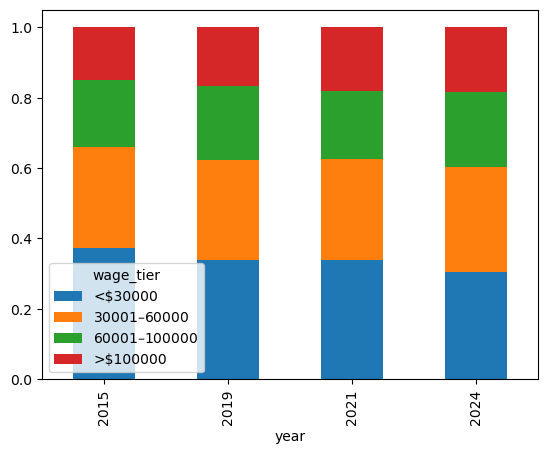

In [27]:
# get factors for cpi adjustment
factors = get_cpi_adjustment_factors(start_year=2015, end_year=2024)

# check the values - they should be larger in the past to get to inflated 2024 dollars
display(factors)
# add constant 2024 dollar version of wages
add_constant_dollar_wage(pums_combo,factors)

# set wage bins
wage_bins = [0, 30_000, 60_000, 100_000, float("inf")]
fmt = ["<$%s", "$%s–$%s", ">$%s"]

# in case we alter the categories - pandas gets mad if the categorical is already there
if 'wage_tier' in pums_combo:
    pums_combo.drop('wage_tier',axis=1,inplace=True)

# bin wages
bin_wage_workers(pums_combo, cutoffs=wage_bins, format_strings=fmt)
pums_combo.groupby(['year','wage_tier']).PWGTP.sum().groupby(level=0,group_keys=False).apply(pct).unstack(1).plot(kind='bar',stacked=True)

## Quick sanity checks 

### Check wagp coding

In [28]:
# sanity check the WAGP_2024 variable is generally larger in the past
pums_combo[['year','WAGP','WAGP_2024','wage_tier']].sample(10)

,year,WAGP,WAGP_2024,wage_tier
5464240,2019,9600.0,11899.172119,<$30000
3741323,2019,0.0,0.000000,NaN
9051234,2021,70000.0,83462.271156,$60001–$100000
11934225,2024,65000.0,65991.250000,$60001–$100000
8627622,2021,2300.0,2742.331767,<$30000
12120737,2024,0.0,0.000000,NaN
6640745,2021,170000.0,202694.087093,>$100000
5805890,2019,0.0,0.000000,NaN
3563761,2019,15600.0,19336.154694,<$30000
9732467,2024,0.0,0.000000,NaN


In [29]:
# chekc ranges for WAGP_2024 falls appropriately within wage_tier categories - looks good
pums_combo.groupby(['year','wage_tier'])[['WAGP_2024']].describe().loc(1)[:,['min','max']].unstack(0)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\3416501770.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pums_combo.groupby(['year','wage_tier'])[['WAGP_2024']].describe().loc(1)[:,['min','max']].unstack(0)


WAGP_2024                                            \
                          min                                             
year                     2015           2019           2021        2024   
wage_tier                                                                 
<$30000              5.301137       4.957988       4.769273       4.061   
$30001–$60000    30083.951963   30119.779427   30046.417616   30051.400   
$60001–$100000   60035.375503   60115.609145   60808.226128   60915.000   
>$100000        100721.601285  100399.264757  100154.725387  100509.750   

                                                                         
                          max                                            
year                     2015           2019           2021        2024  
wage_tier                                                                
<$30000          29951.423540   29995.829718   29927.185800   29949.875  
$30001–$60000    59902.847080   59991.659435   59615.907969   59899.750  
$60001–$100000   99396.317058   99159.767662   98962.407228   99494.500  
>$100000        872037.021652  888719.417666  938354.391426  920831.750

### Check population totals by region
Bay area: 7.6m; SCAG: 18.6m / looks kosher.

In [30]:
pums_combo.groupby(['year','ca_regions_res']).PWGTP.sum().unstack('year')

year,2015,2019,2021,2024
ca_regions_res,,,,
ABAG/MTC,7653334,7740272,7584845,7648367
AMBAG,768291,769672,771440,767947
MCAG,268553,277872,286391,296609
Rest of CA,152174,150589,159695,156769
SACOG,2446871,2539260,2594151,2649267
SANDAG,3299170,3338514,3286940,3300626
SCAG,18863847,18891698,18668516,18687047
SJCOG,726209,762226,789754,817008
STANCOG,538021,550129,552981,556715


In [31]:
# place of work totals by region
pums_combo.groupby(['year','ca_regions_wrk']).PWGTP.sum().unstack('year')

year,2015,2019,2021,2024
ca_regions_wrk,,,,
ABAG/MTC,3880809,4147447,3895704,4084422
AMBAG,323926,328828,314687,321765
MCAG,81142,83816,83817,96583
Rest of CA,53643,57397,54833,55582
SACOG,1038897,1161698,1142063,1219227
SANDAG,1623925,1701146,1617630,1716915
SCAG,8472733,8968741,8431262,9016756
SJCOG,253186,282582,298027,317981
STANCOG,188648,201792,203682,205874


## Universe / segment construction
We do a few upfront subsets so we can run summaries easier later on those subeset

In [32]:
residents_ca_reg = pums_combo.query(' ca_regions_res!="outside ca COGs"')

In [33]:
residents_ca_reg.groupby(['year','in_lf','ca_regions_res']).PWGTP.sum().groupby(level=['year','ca_regions_res'],group_keys=False).apply(pct).loc[:,True].unstack(1)

ca_regions_res,ABAG/MTC,AMBAG,MCAG,Rest of CA,SACOG,SANDAG,SCAG,SJCOG,STANCOG
year,,,,,,,,,
2015,0.510753,0.456160,0.370895,0.399260,0.444943,0.495605,0.463603,0.407205,0.398248
2019,0.531950,0.476726,0.408918,0.412812,0.474520,0.512357,0.487993,0.433012,0.430479
2021,0.507021,0.457813,0.373612,0.400814,0.460927,0.494063,0.466793,0.420893,0.426836
2024,0.524864,0.468812,0.426066,0.396794,0.476308,0.518275,0.497138,0.443419,0.439855


In [34]:
# flow summary - commuters
workflows = pums_combo.query('in_lf').groupby(['year','ca_regions_res','ca_regions_wrk']).PWGTP.sum().unstack(1)

In [35]:
# flow summary - movers / migrants
migflows = pums_combo.query('is_mover').groupby(['year','ca_regions_res','ca_regions_res_prior']).PWGTP.sum().unstack(1)
migflows.head()

ca_regions_res             ABAG/MTC    AMBAG     MCAG  Rest of CA     SACOG  \
year ca_regions_res_prior                                                     
2015 ABAG/MTC              683414.0  10678.0   2797.0      2786.0   23581.0   
     AMBAG                   8398.0  55852.0    211.0        41.0    2025.0   
     MCAG                     427.0    453.0  21927.0         NaN    2998.0   
     Rest of CA              2879.0      NaN      NaN     15591.0     498.0   
     SACOG                  17682.0   1784.0    460.0       211.0  273174.0   

ca_regions_res             SANDAG     SCAG    SJCOG  STANCOG  outside ca COGs  
year ca_regions_res_prior                                                      
2015 ABAG/MTC              5950.0  29323.0  16585.0   6308.0         141573.0  
     AMBAG                 1049.0   3471.0    248.0    902.0          23836.0  
     MCAG                     NaN   2499.0    239.0   3061.0           4906.0  
     Rest of CA               NaN    382.0      NaN      NaN           4315.0  
     SACOG                  684.0  12272.0   4462.0   1111.0          53465.0

In [36]:
bay_area_workers_inclusive = pums_combo.query('bay_area_workplace & in_lf')

In [37]:
# folks who work in the the region but don't live in the region 

bay_area_workers = pums_combo.query('bay_area_workplace & ~bay_area_this_year & in_lf')

In [38]:
# folks who was not in the bay area the prior year, but where here this year - and (thereby) was a mover

bay_area_inmigrants = pums_combo.loc[(~pums_combo.bay_area_last_year) & (pums_combo.bay_area_this_year) & (pums_combo.is_mover)]
bay_area_inmigrants.head()

,SERIALNO,PUMA,STATE,ADJINC,PWGTP,AGEP,JWMNP,JWTR,MIG,RELP,...,work_bayarea_w_nbhs,county_res,naics_2,is_info,is_prof,in_lf,sex,age_cat,WAGP_2024,wage_tier
150746,96,9703,6,1001264,114,32,NaN,NaN,3.0,15.0,...,Further afield,Sonoma,99,False,False,False,female,26-35,0.000000,NaN
150843,498,110,6,1001264,90,49,NaN,NaN,2.0,8.0,...,Further afield,Alameda,NaN,False,False,False,female,46-55,0.000000,NaN
151188,2003,8512,6,1001264,62,90,NaN,NaN,2.0,8.0,...,Further afield,Santa Clara,NaN,False,False,False,female,> 65,0.000000,NaN
151205,2070,8509,6,1001264,80,69,NaN,NaN,3.0,6.0,...,Further afield,Santa Clara,72,False,False,False,female,> 65,0.000000,NaN
151361,2742,9703,6,1001264,81,31,20.0,1.0,3.0,15.0,...,Sonoma County,Sonoma,72,False,False,True,male,26-35,6626.421137,<$30000


In [39]:
# folks who moved last year from the bay area to somerwhere else

bay_area_outmigrants = pums_combo.loc[(pums_combo.bay_area_last_year) & (~pums_combo.bay_area_this_year) & (pums_combo.is_mover)]
bay_area_outmigrants.head()

,SERIALNO,PUMA,STATE,ADJINC,PWGTP,AGEP,JWMNP,JWTR,MIG,RELP,...,work_bayarea_w_nbhs,county_res,naics_2,is_info,is_prof,in_lf,sex,age_cat,WAGP_2024,wage_tier
6472,209425,100,1,1001264,43,20,NaN,NaN,3.0,17.0,...,Further afield,outside ca,45,False,False,False,male,16-25,530.113691,<$30000
16689,531768,1600,1,1001264,82,18,NaN,NaN,3.0,17.0,...,Further afield,outside ca,61,False,False,False,male,16-25,3180.682146,<$30000
18734,601121,100,1,1001264,8,20,NaN,NaN,3.0,17.0,...,Further afield,outside ca,45,False,False,False,male,16-25,530.113691,<$30000
26137,836453,2701,1,1001264,266,36,15.0,1.0,3.0,0.0,...,Further afield,outside ca,48,False,False,True,female,36-45,8879.404324,<$30000
26138,836453,2701,1,1001264,228,14,NaN,NaN,3.0,2.0,...,Further afield,outside ca,NaN,False,False,False,male,< 15,NaN,NaN


In [40]:
# folks who are in lf and in the region now

bay_area_lf = pums_combo.loc[(pums_combo.bay_area_this_year) & (pums_combo.in_lf)]

In [41]:
lf_prof_wfh = pums_combo.query('in_lf & wfh & is_prof')
lf_prof = pums_combo.query('in_lf & is_prof')

In [42]:
lf_prof_by_region = lf_prof_wfh.groupby(
    ['year','ca_regions_res'], observed=True).apply(estimate_total_with_se)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1874054350.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['year','ca_regions_res'], observed=True).apply(estimate_total_with_se)


In [43]:
lf_prof_whf_by_region = lf_prof_wfh.groupby(
    ['year','ca_regions_res'], observed=True).apply(estimate_total_with_se)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\721200202.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['year','ca_regions_res'], observed=True).apply(estimate_total_with_se)


In [44]:
pd.options.display.float_format = '{:,.0f}'.format
workers_by_wfh = pums_combo.query('in_lf').groupby(
    ['year','ca_regions_res','wfh'], observed=True).apply(estimate_total_with_se)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1500948795.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['year','ca_regions_res','wfh'], observed=True).apply(estimate_total_with_se)


In [45]:
pd.options.display.float_format = '{:,.3f}'.format
workers_by_wfh.total.groupby(level=['year','ca_regions_res','wfh']).sum().groupby(level=[0,1],group_keys=False).apply(pct).loc[:,:,True].unstack(1)

ca_regions_res,ABAG/MTC,AMBAG,MCAG,Rest of CA,SACOG,SANDAG,SCAG,SJCOG,STANCOG,outside ca COGs
year,,,,,,,,,,
2015,0.055,0.050,0.044,0.101,0.058,0.067,0.052,0.048,0.043,0.044
2019,0.062,0.058,0.034,0.105,0.074,0.072,0.059,0.039,0.041,0.055
2021,0.316,0.158,0.076,0.123,0.214,0.217,0.187,0.105,0.088,0.170
2024,0.165,0.097,0.058,0.115,0.155,0.158,0.135,0.101,0.075,0.129


In [46]:
pd.options.display.float_format = '{:,.3f}'.format
workers_by_wfh.total.groupby(level=['year','ca_regions_res','wfh']).sum().groupby(level=[0,1],group_keys=False).apply(pct).loc[:,:,False].unstack(1)

ca_regions_res,ABAG/MTC,AMBAG,MCAG,Rest of CA,SACOG,SANDAG,SCAG,SJCOG,STANCOG,outside ca COGs
year,,,,,,,,,,
2015,0.945,0.950,0.956,0.899,0.942,0.933,0.948,0.952,0.957,0.956
2019,0.938,0.942,0.966,0.895,0.926,0.928,0.941,0.961,0.959,0.945
2021,0.684,0.842,0.924,0.877,0.786,0.783,0.813,0.895,0.912,0.830
2024,0.835,0.903,0.942,0.885,0.845,0.842,0.865,0.899,0.925,0.871


In [47]:
workers_by_wfh.loc(0)[:,:,True].total.unstack(1)

,ca_regions_res,ABAG/MTC,AMBAG,MCAG,Rest of CA,SACOG,SANDAG,SCAG,SJCOG,STANCOG,outside ca COGs
year,wfh,,,,,,,,,,
2015,True,"215,604.000","17,677.000","4,334.000","6,144.000","63,532.000","110,122.000","452,194.000","14,269.000","9,204.000","5,967,925.000"
2019,True,"257,223.000","21,448.000","3,859.000","6,503.000","89,223.000","123,687.000","547,785.000","12,735.000","9,609.000","7,896,802.000"
2021,True,"1,215,989.000","55,976.000","8,135.000","7,861.000","256,374.000","352,793.000","1,633,622.000","35,030.000","20,695.000","24,047,050.000"
2024,True,"664,059.000","34,936.000","7,277.000","7,166.000","195,892.000","271,096.000","1,249,814.000","36,716.000","18,335.000","19,562,385.000"


In [48]:
pd.options.display.float_format = '{:,.0f}'.format
pums_combo.query('in_lf').query('ca_regions_res=="ABAG/MTC"').groupby(
    ['year','ca_regions_res','wfh'], observed=True).apply(estimate_total_with_se)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1004585968.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['year','ca_regions_res','wfh'], observed=True).apply(estimate_total_with_se)


total     se    moe  ci_lower  ci_upper  cv  \
year ca_regions_res wfh                                                     
2015 ABAG/MTC       False 3,693,362 12,642 20,796 3,672,567 3,714,158   0   
                    True    215,604  5,544  9,121   206,484   224,725   0   
2019 ABAG/MTC       False 3,860,216 15,259 25,101 3,835,115 3,885,318   0   
                    True    257,223  6,740 11,087   246,137   268,310   0   
2021 ABAG/MTC       False 2,629,686 14,762 24,283 2,605,404 2,653,969   0   
                    True  1,215,989 11,098 18,256 1,197,733 1,234,246   0   
2024 ABAG/MTC       False 3,350,292 16,827 27,680 3,322,613 3,377,972   0   
                    True    664,059 10,770 17,716   646,344   681,775   0   

                           sample_size  
year ca_regions_res wfh                 
2015 ABAG/MTC       False       35,361  
                    True         2,252  
2019 ABAG/MTC       False       37,480  
                    True         2,787  
2021 ABAG/MTC       False       25,345  
                    True        13,084  
2024 ABAG/MTC       False       32,802  
                    True         7,084

In [49]:
bay_area_lf.groupby(['year','county_name']).PWGTP.sum().unstack(1).sum(axis=1)

year
2015    3908966
2019    4117439
2021    3845675
2024    4014351
dtype: int64

# Summaries

In [50]:
out_path = M_DRIVE / 'Projects/Worker Flows'
#bay_area_workers_inclusive.to_csv(out_path / 'bay_area_workers_inclusive.csv')

## Out of region workers
### by origin region

In [51]:
# living elsewhere, working here

(bay_area_workers
 .groupby(['year','ca_regions_res'])
 .apply(estimate_total_with_se)#.unstack(0)
# .plot(kind='bar')
).total.unstack('year')

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\2750467778.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_total_with_se)#.unstack(0)


year,2015,2019,2021,2024
ca_regions_res,,,,
AMBAG,"33,801","43,503","39,948","40,293"
MCAG,"8,771","10,034","9,288","9,383"
Rest of CA,"6,516","5,591","7,582","6,897"
SACOG,"30,345","42,882","32,763","39,875"
SANDAG,"2,344","2,901","1,833","2,049"
SCAG,"12,534","11,809","7,830","10,671"
SJCOG,"55,676","65,269","51,677","60,739"
STANCOG,"15,331","22,363","19,190","19,491"
outside ca COGs,"35,387","40,602","31,281","36,962"


## Commissioner Burt Request: Flows in/out
See [asana: Inquiry from Commissioner Burt re: inbound megacommuters](https://app.asana.com/1/11860278793487/project/310827677834656/task/1213318305068037?focus=true)

In [52]:
tables = {
    'table_1':'Inbound By Origin County',
    'table_2':'Inbound by Wage Category',
    'table_3':'Commute Matrix',
    'table_4':'Overall Flows',
    'table_5':'Megacommuters'
         }

In [53]:
wb = pd.ExcelWriter(out_path / 'commute_flows_summary_sheet.xlsx')

In [54]:
# matrix_aggregate = pums_combo.query('in_lf').groupby(['year','res_vicinity','work_vicinity']).PWGTP.sum().loc[2024].unstack(1)

### Table 1 Inbound by Origin County

In [55]:
# living elsewhere, working here

table_1 = (bay_area_workers
 .groupby(['year','ca_regions_res','county_name'])
 .apply(estimate_total_with_se)#.unstack(0)
).total.unstack('year')
table_1.reset_index().to_excel(wb,tables['table_1'],index=False)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\3731217825.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_total_with_se)#.unstack(0)
C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\3731217825.py:7: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  table_1.reset_index().to_excel(wb,tables['table_1'],index=False)


### Table 2 Inbound by Wage Category

In [56]:
# living elsewhere, working here

table_2 =  (bay_area_workers
 .groupby(['year','wage_tier'])
 .apply(estimate_total_with_se)#.unstack(0)
) 
table_2.total.unstack('year').reset_index().to_excel(wb,tables['table_2'],index=False)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1968805707.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year','wage_tier'])
C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1968805707.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_total_with_se)#.unstack(0)
C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1968805707.py:7: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  table_

### Table 3 overall county ot county flows

In [57]:
matrix_county = pums_combo.query('in_lf ').groupby(['year','res_vicinity','res_bayarea_w_nbhs','work_vicinity','work_bayarea_w_nbhs'],observed=True).PWGTP.sum()

table_3 = matrix_county.loc[2024].unstack(level=[2,3]).sort_index(axis=1,level=1).sort_index(axis=0,level=1)

# bay_area_workers[['WAGP','wage_tier']].sample(100)
table_3.to_excel(wb,tables['table_3'],index=True)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\226631816.py:6: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  table_3.to_excel(wb,tables['table_3'],index=True)


### Table 4 Overall flows / inbound outbound wrt region

In [58]:
# the inverse: bay area residents, rest of the country workers

outbound_flow =  (pums_combo.query('~bay_area_workplace & bay_area_this_year & in_lf')
 .groupby(['year'])
 .apply(estimate_total_with_se)
)

outbound_flow

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\2239819031.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_total_with_se)


,total,se,moe,ci_lower,ci_upper,cv,sample_size
year,,,,,,,
2015,"228,862","6,193","10,188","218,674","239,051",0,"1,875"
2019,"214,946","6,909","11,366","203,581","226,312",0,"1,715"
2021,"151,363","5,139","8,454","142,910","159,817",0,"1,408"
2024,"156,289","5,444","8,956","147,333","165,246",0,"1,468"


In [59]:
inbound_flow = (bay_area_workers
 .groupby(['year'])
 .apply(estimate_total_with_se)#.unstack(0)
)
inbound_flow

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\1721297292.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_total_with_se)#.unstack(0)


,total,se,moe,ci_lower,ci_upper,cv,sample_size
year,,,,,,,
2015,"200,705","5,954","9,794","190,911","210,500",0,"1,819"
2019,"244,954","6,601","10,859","234,095","255,814",0,"2,168"
2021,"201,392","6,352","10,449","190,943","211,842",0,"1,675"
2024,"226,360","6,279","10,330","216,031","236,690",0,"2,137"


In [60]:
table_4 = pd.concat([outbound_flow.total,inbound_flow.total],keys=['Outbound','Inbound'],axis=1)
table_4.reset_index().to_excel(wb,tables['table_4'],index=False)

C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\521734611.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  table_4.reset_index().to_excel(wb,tables['table_4'],index=False)


### Table 5 Megacommuters

Definitions from the [Census Bureau](https://www.census.gov/content/dam/Census/library/working-papers/2013/demo/SEHSD-WP2013-03_poster.pdf)
* Extreme Commuting: Traveling 90 or more minutes to work.
* Long-distance Commuting: Traveling 50 or more miles to
work.
* Mega Commuting: Traveling 90 or more minutes and 50 or more miles to work.

In [61]:
extremecommuters = (bay_area_workers.query('is_extremecommuter')
 .groupby(['year','ca_regions_res'])
 .apply(estimate_total_with_se)#.unstack(0)
)

table_5 = extremecommuters.total.unstack(0)
table_5.reset_index().to_excel(wb,tables['table_5'],index=False)


C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\821282800.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_total_with_se)#.unstack(0)
C:\Users\aolsen\AppData\Local\Temp\ipykernel_39676\821282800.py:7: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  table_5.reset_index().to_excel(wb,tables['table_5'],index=False)


In [62]:
# close the workbook writer
wb.close()